# Exploratory Data Analysis — Agriculture-Vision (Adaptado)

## Dataset

O dataset utilizado é o **Agriculture-Vision 2022**, disponível em:  
- [Agriculture-Vision Challenge 2022](https://www.agriculture-vision.com/agriculture-vision-2022/prize-challenge-2022/agriculture-vision-challenge-2022)

O dataset tem as seguintes características:
- é para segmentação;
- 10 tipos diferentes de anotações (9 classes + background);
- as imagens são nomeadas conforme o padrão **(field id)_(x1)-(y1)-(x2)-(y2).(jpg/png)**
    - >*"Each field id uniquely identifies the farmland that the image is cropped from, and (x1, y1, x2, y2) is a 4-tuple indicating the position in which the image is cropped."*
- As classes podem ter *overlapping* (sobreposição);

| ID | Classe |
|:---:|:---|
| **0** | background |
| **1** | double_plant |
| **2** | drydown |
| **3** | endrow |
| **4** | nutrient_deficiency |
| **5** | planter_skip |
| **6** | water |
| **7** | waterway |
| **8** | weed_cluster |
| **9** | storm_damage |

### Fonte
E as informações prestadas aqui, foram oriundas, além da [página do dataset](https://www.agriculture-vision.com/agriculture-vision-2022/prize-challenge-2022/agriculture-vision-challenge-2022), também dos trabalhos:
- [Agriculture-Vision: A Large Aerial Image Database for Agricultural Pattern Analysis](https://ieeexplore.ieee.org/document/9157397)
- [The 1st Agriculture-Vision Challenge: Methods and Results](https://ieeexplore.ieee.org/document/9150731)

## Adaptação do Split de Test

O dataset original não possui *ground truth* para o split de **test**, impossibilitando avaliação quantitativa. A adaptação adotada foi derivar o split de test a partir do **split de validação oficial**, seguindo a mesma lógica descrita no paper original — splitar por *farmland*, não por crop individual:

> *"We first randomly split the 3,432 farmland images with a 6/2/2 train/val/test ratio. We then assign each sampled image to the split of the farmland image they are cropped from."*

Assim, o split de validação oficial foi dividido em **val** (50% dos farmlands) e **test** (50% dos farmlands), essa divisão por farmland evita o data leakeage.

In [1]:
from src.utils import *
from src.data import *
from src.constants import DATASET_DIR, INPUT_CHANNELS, CLASSES2EVAL, IS_SPLIT_VALIDATION_SET, TAX_FOR_VALIDATION_SET, BATCH_SIZE, SEED

## Configuração

O caminho para o dataset deve estar definido no arquivo `config.yaml` na raiz do projeto, seguindo o exemplo:

```yaml
dataset_path: /caminho/da/base/dos/arquivos/do/dataset
```

O diretório indicado deve conter os subdiretórios `train/`, `val/` e `test/`.

In [2]:
from pathlib import Path

p = Path(DATASET_DIR).expanduser().resolve()
print(f"DATASET_DIR (configurado): {DATASET_DIR}")
print(f"DATASET_DIR (resolvido):   {p}")
print(f"Existe? {'Sim' if p.exists() else 'Nao'}")
print(f"E diretorio? {'Sim' if p.is_dir() else 'Nao'}")

for split in ("train", "val", "test"):
    split_path = p / split
    print(f"{split:<5}: {'OK' if split_path.is_dir() else 'FALTANDO'} -> {split_path}")

DATASET_DIR (configurado): /home/bizzo/Programas/unicamp/IA901-2026S1/projetos/Multiespectral Agrícola/data/dataset/supervised/Agriculture-Vision-2021
DATASET_DIR (resolvido):   /home/bizzo/Programas/unicamp/IA901-2026S1/projetos/Multiespectral Agrícola/data/dataset/supervised/Agriculture-Vision-2021
Existe? Sim
E diretorio? Sim
train: OK -> /home/bizzo/Programas/unicamp/IA901-2026S1/projetos/Multiespectral Agrícola/data/dataset/supervised/Agriculture-Vision-2021/train
val  : OK -> /home/bizzo/Programas/unicamp/IA901-2026S1/projetos/Multiespectral Agrícola/data/dataset/supervised/Agriculture-Vision-2021/val
test : OK -> /home/bizzo/Programas/unicamp/IA901-2026S1/projetos/Multiespectral Agrícola/data/dataset/supervised/Agriculture-Vision-2021/test


In [3]:
data_module = AgricultureVisionDataModule(
        dataset_dir=DATASET_DIR,
        input_channels=INPUT_CHANNELS,
        classes2eval=CLASSES2EVAL,
        isSplitValidationSet=IS_SPLIT_VALIDATION_SET,
        taxForValidationSet=TAX_FOR_VALIDATION_SET,
        batch_size=BATCH_SIZE,
        seed=SEED)

In [4]:
data_module.setup()
train_dataset = data_module.train_dataset
val_dataset = data_module.val_dataset
test_dataset = data_module.test_dataset

## Visualização de amostras de imagens do dataset.

Para treinamento do modelo, têm-se imagens RGB, Near-infrared, imagens binárias (Mask e Boundary) e as classes dos labels. O NDVI foi calculado; apenas a fins de informação 

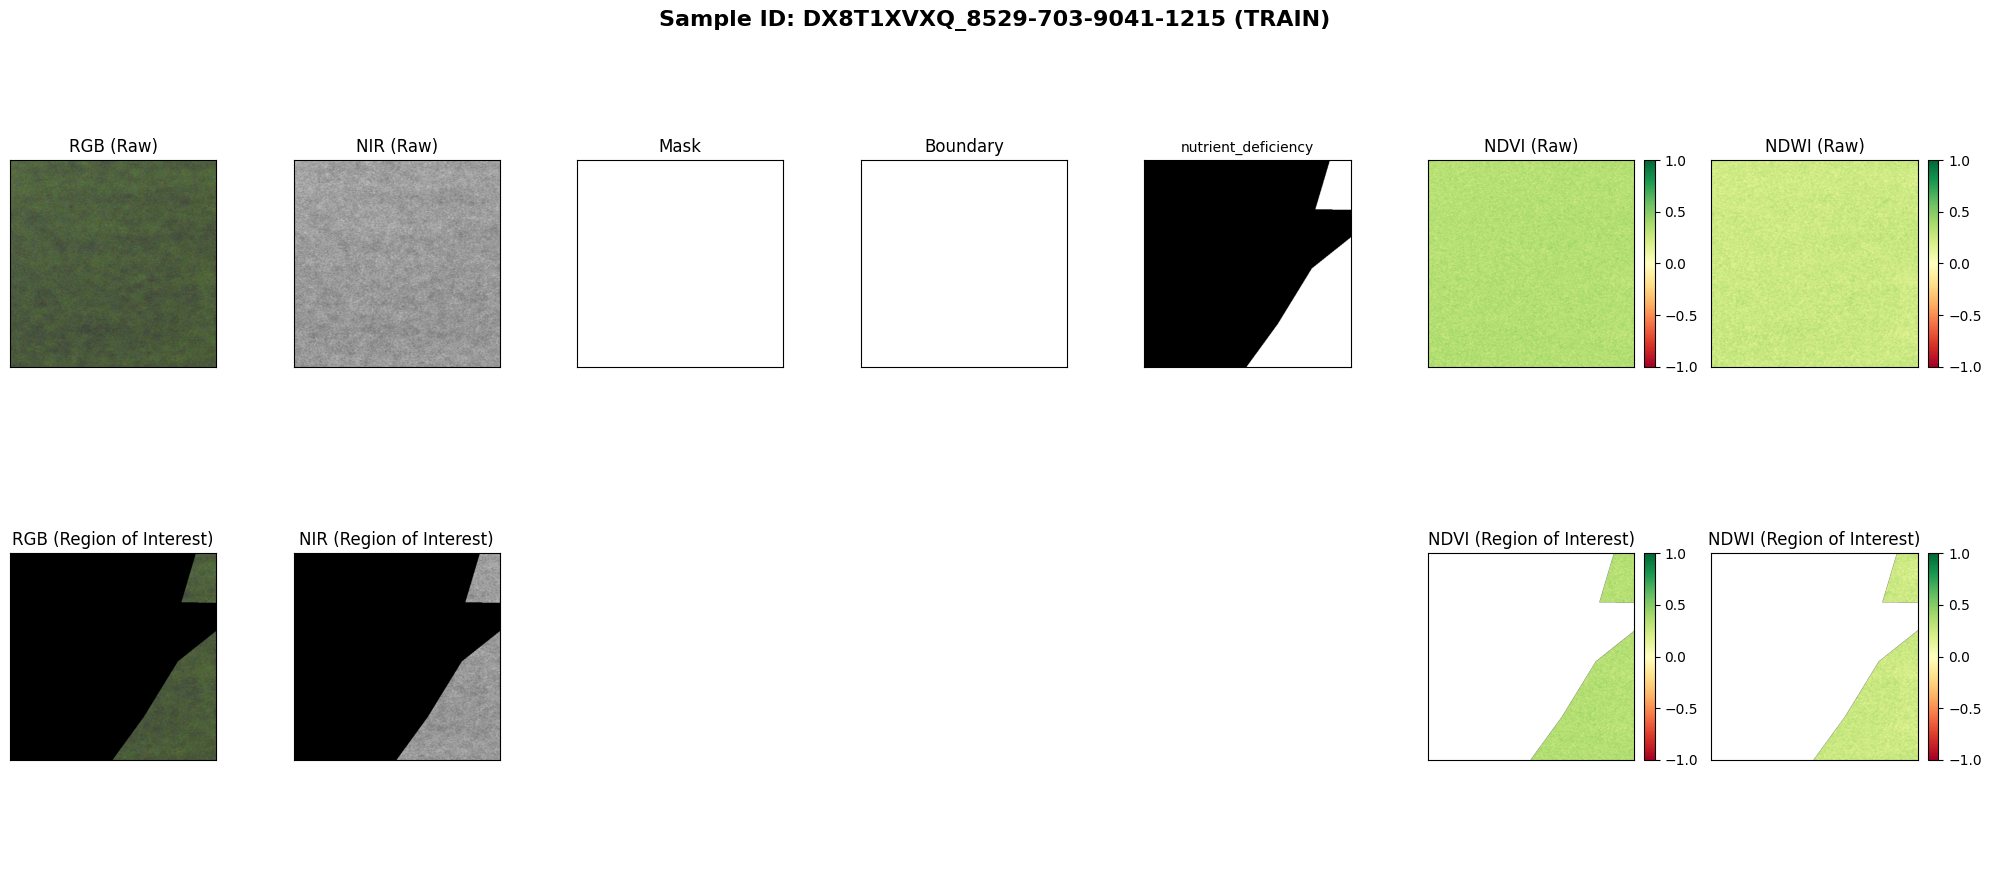

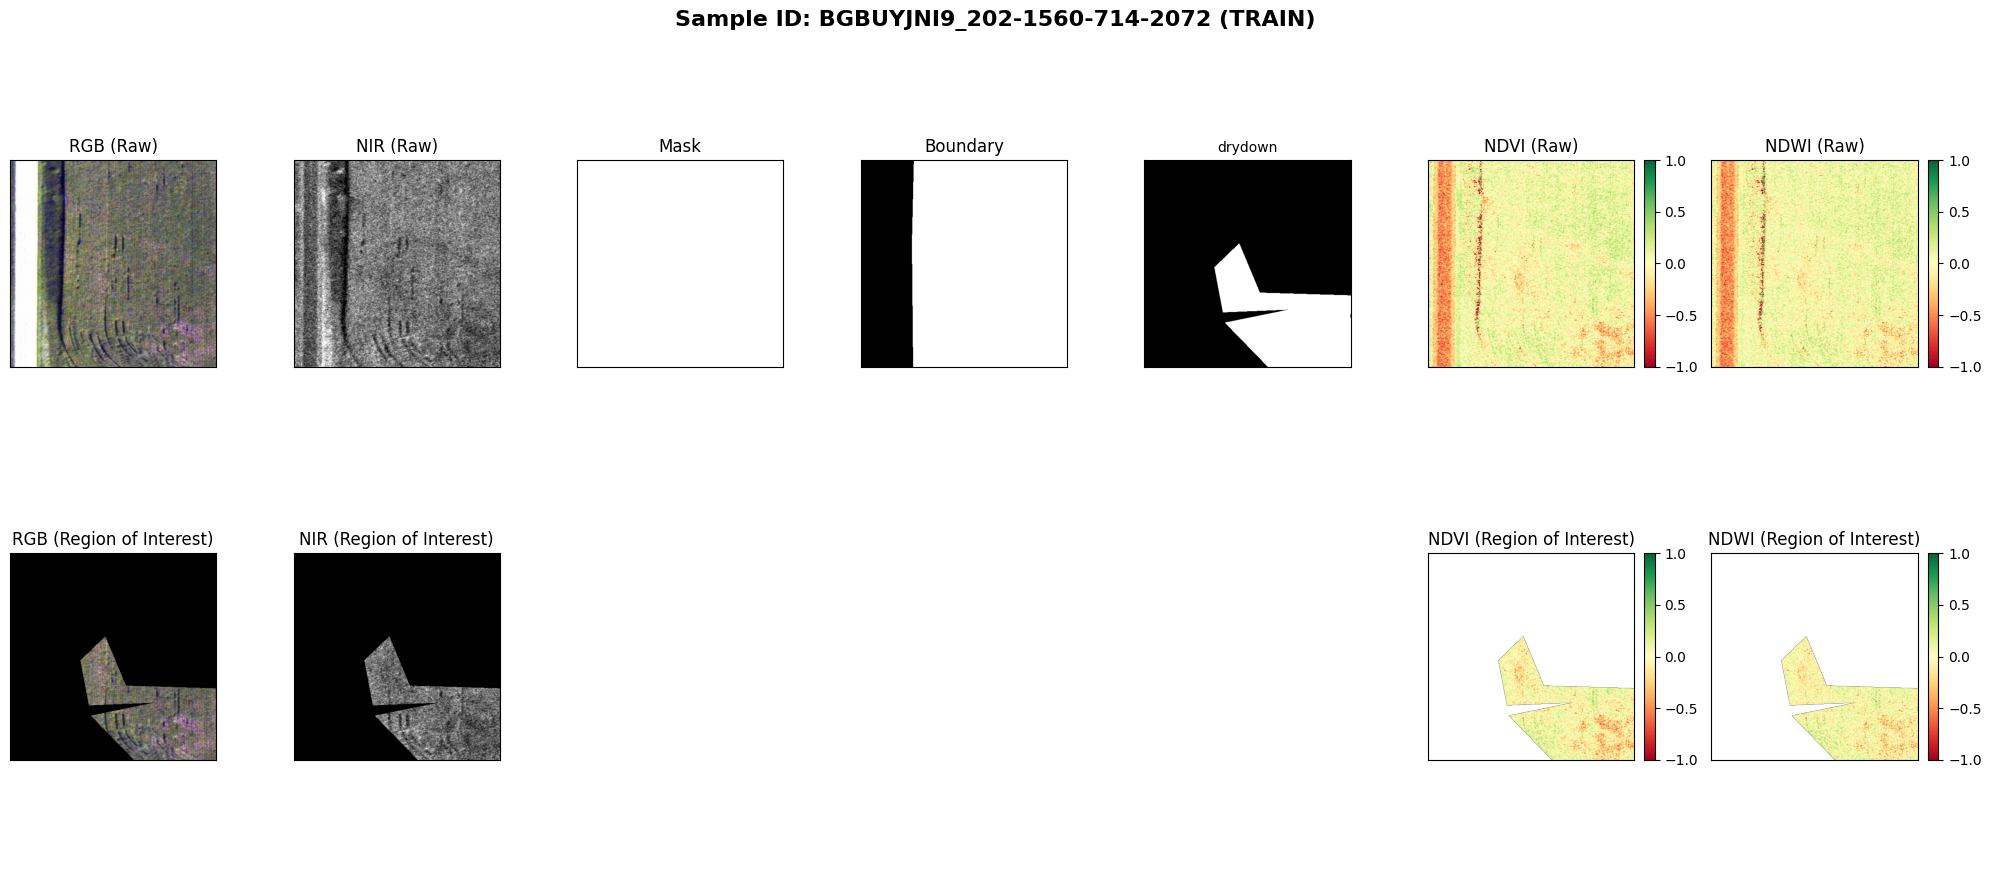

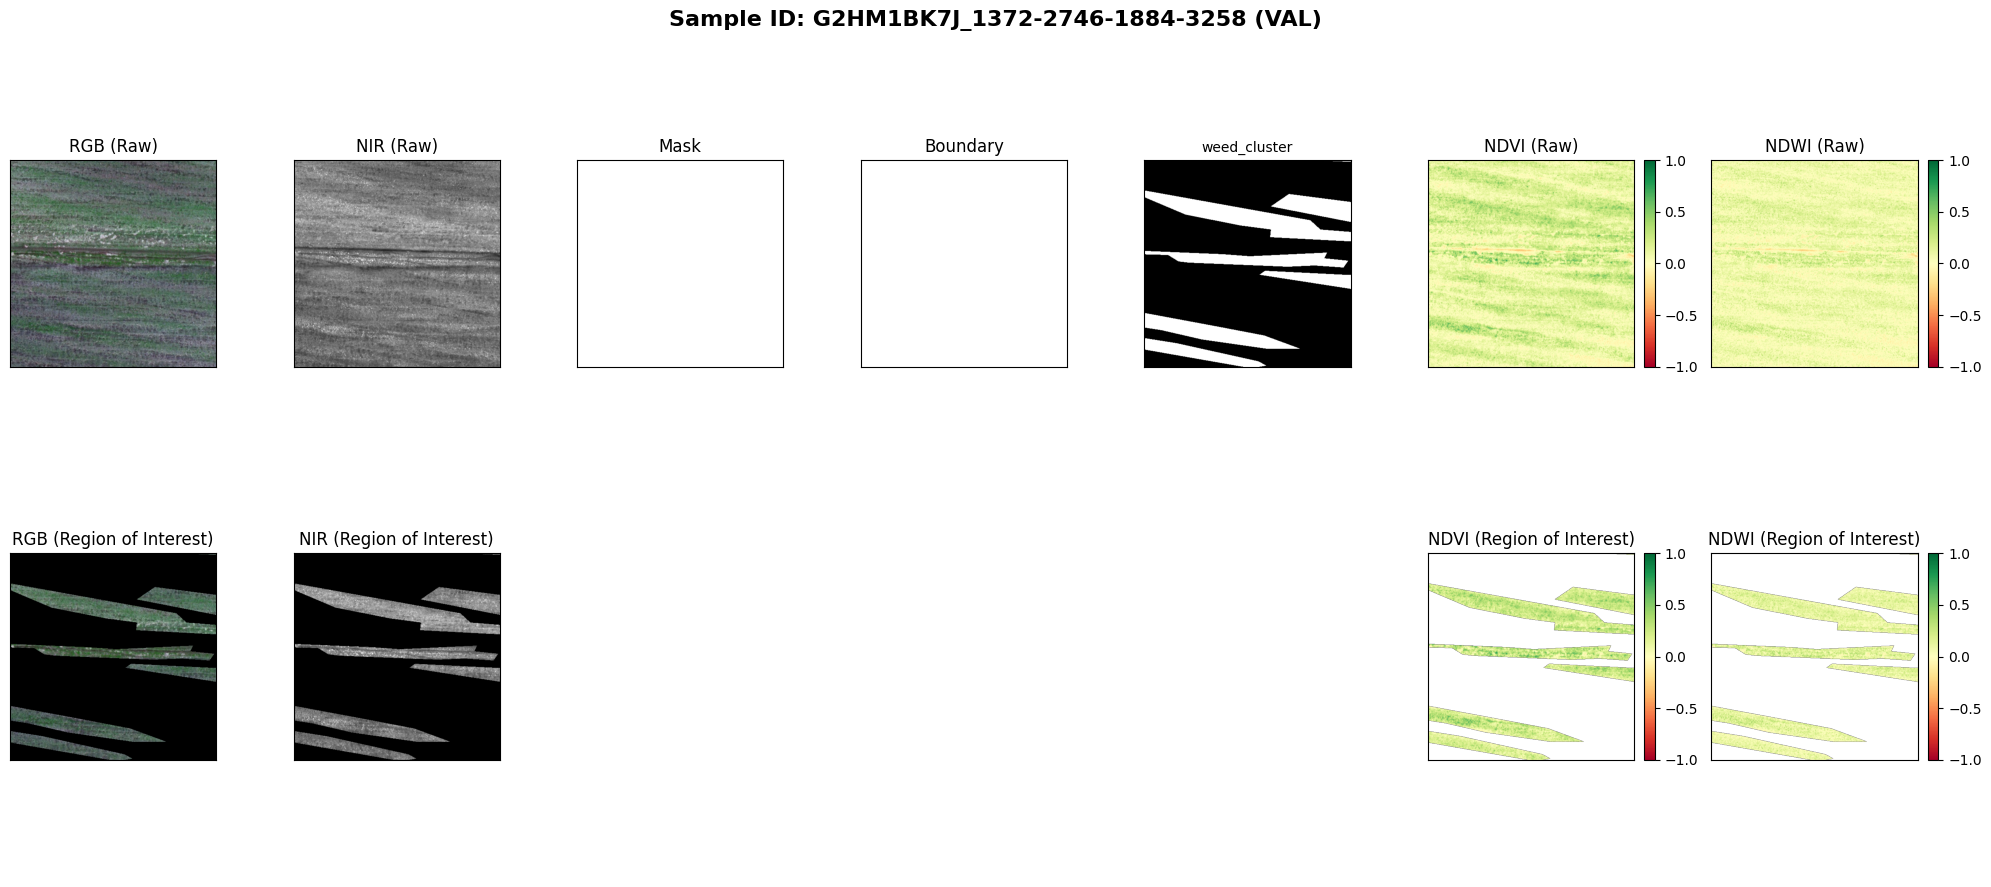

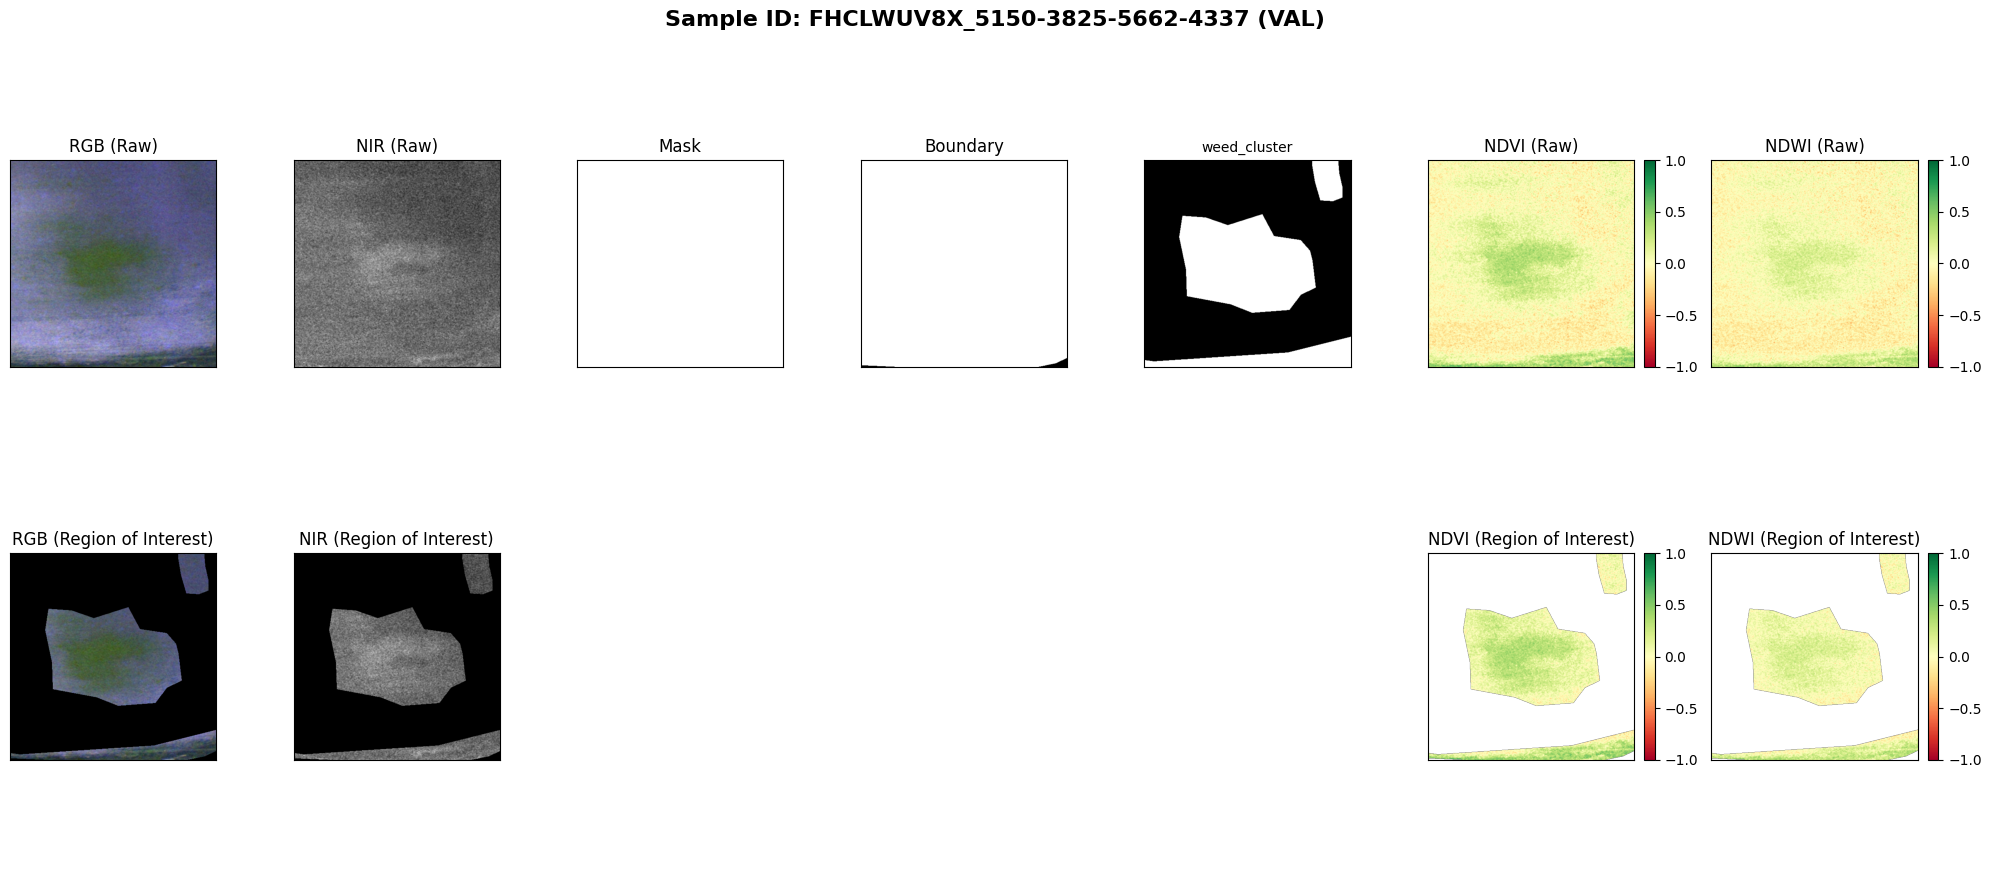

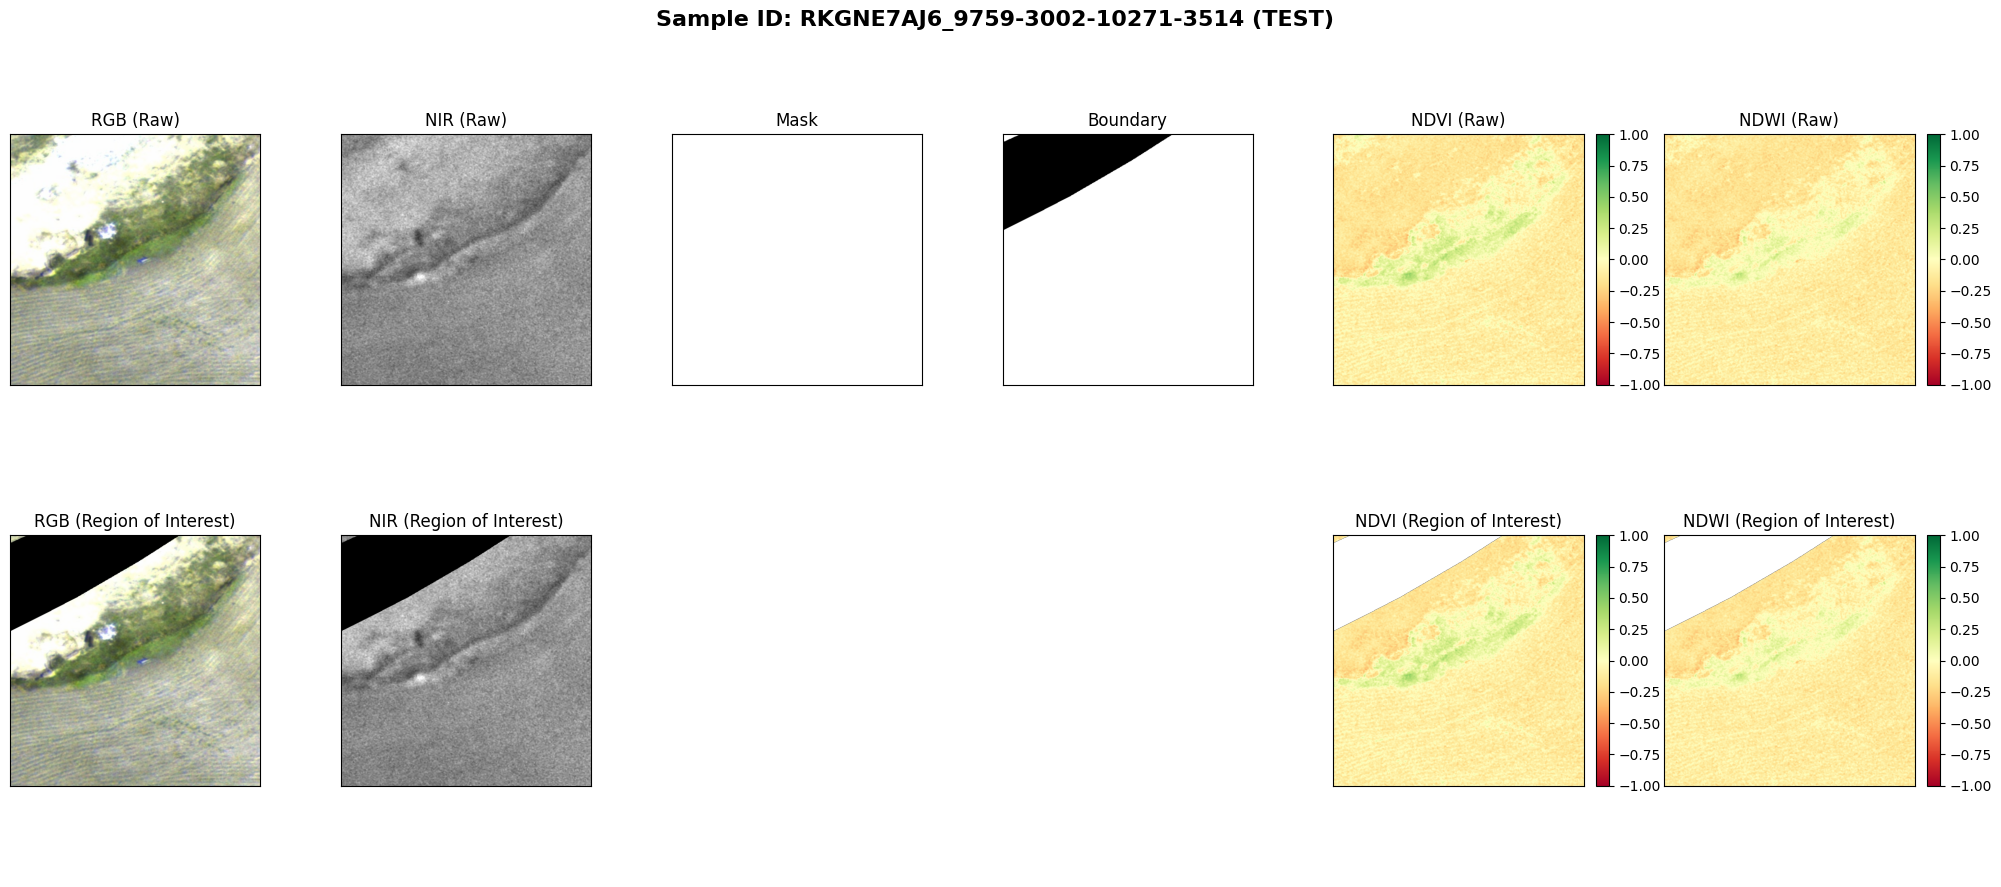

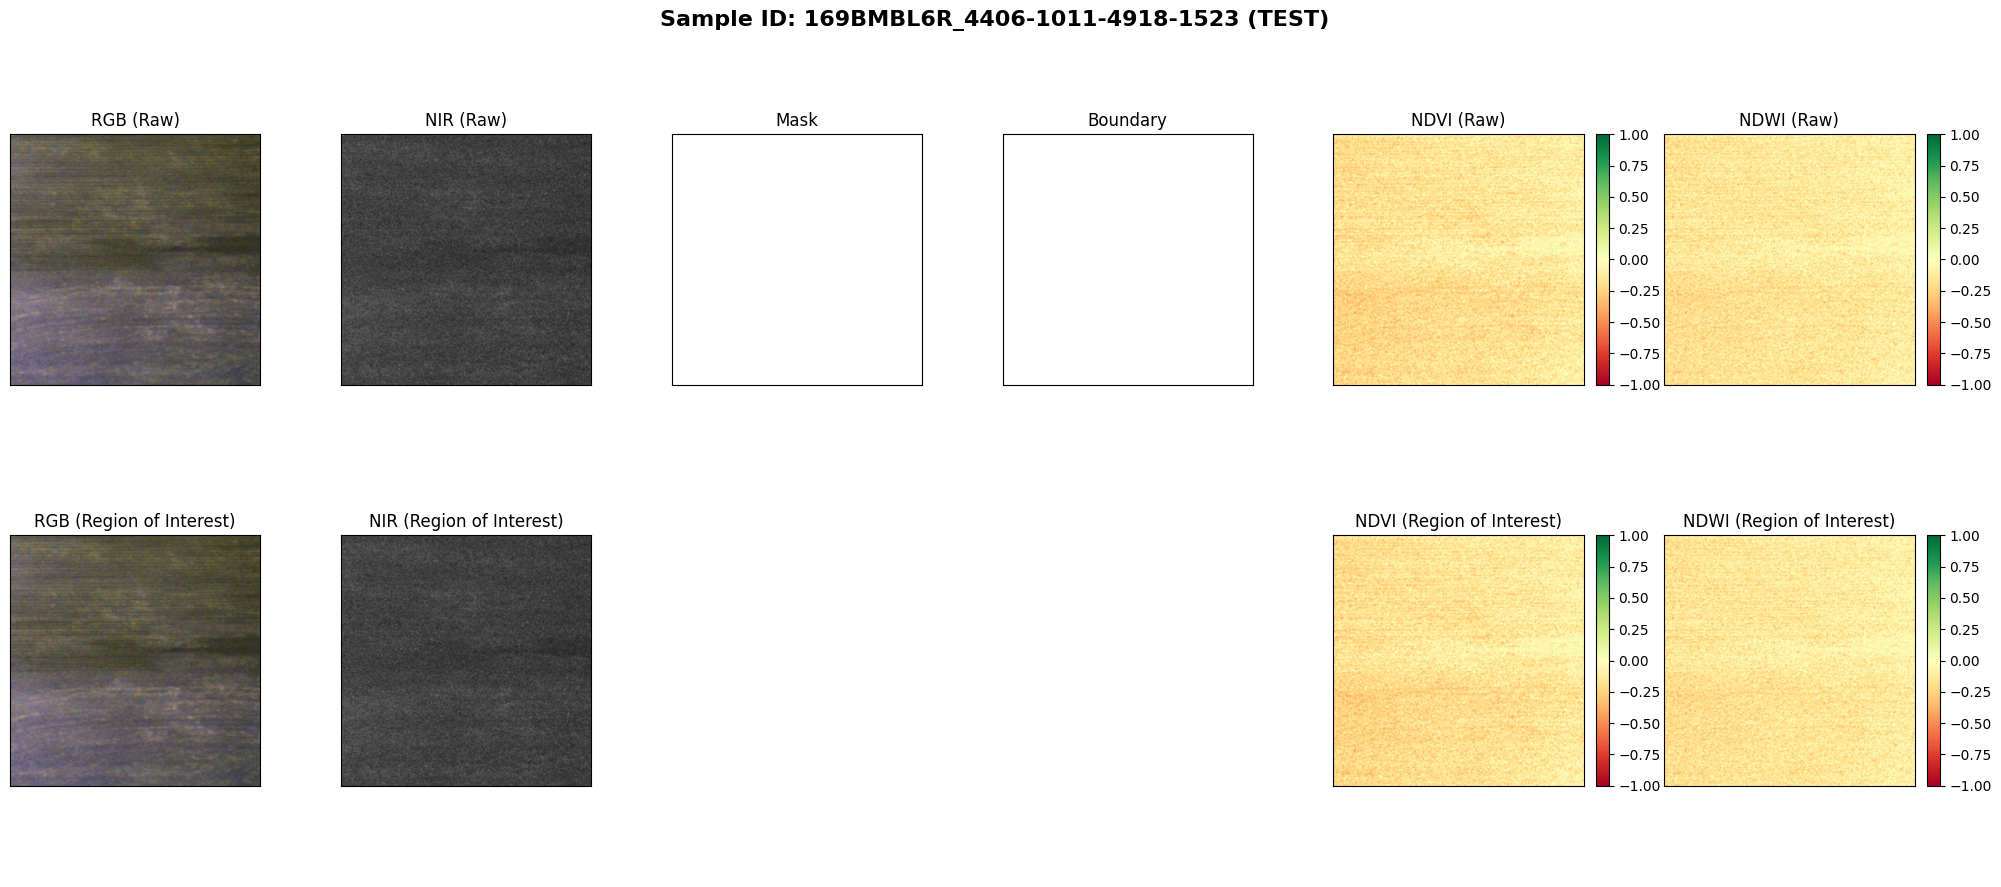

In [5]:
exploratory_data_analysis.show_samples('Train', train_dataset, num_amostras=2)
exploratory_data_analysis.show_samples('Val', val_dataset, num_amostras=2)
exploratory_data_analysis.show_samples('Test', test_dataset, num_amostras=2)

## Comparativo entre os splits de treino, validação e teste do dataset adaptado

Abaixo faremos alguns gráficos para entender melhor a distribuição das classes e a quantidade de amostras em cada split.

In [6]:
metricas_train, metricas_val, metricas_test = exploratory_data_analysis.get_stats_from_splits(train_dataset, val_dataset, test_dataset)

## Frequência das Classes por Imagem

Cada barra indica em quantas imagens daquele split a classe aparece ao menos uma vez. O dataset é **multi-label**: uma mesma imagem pode conter mais de uma classe simultaneamente.

`drydown` e `nutrient_deficiency` dominam os três splits, enquanto `storm_damage` é a classe mais rara — e **ausente no Test** (0,0%). Todas as farmlands com essa anotação ficaram concentradas em Train e Val, o que impossibilita avaliação quantitativa de `storm_damage` no conjunto de teste. Logo, seguindo a mesma orientação do paper, não iremos incluir essa classe para o desenvolvimento dos modelos.

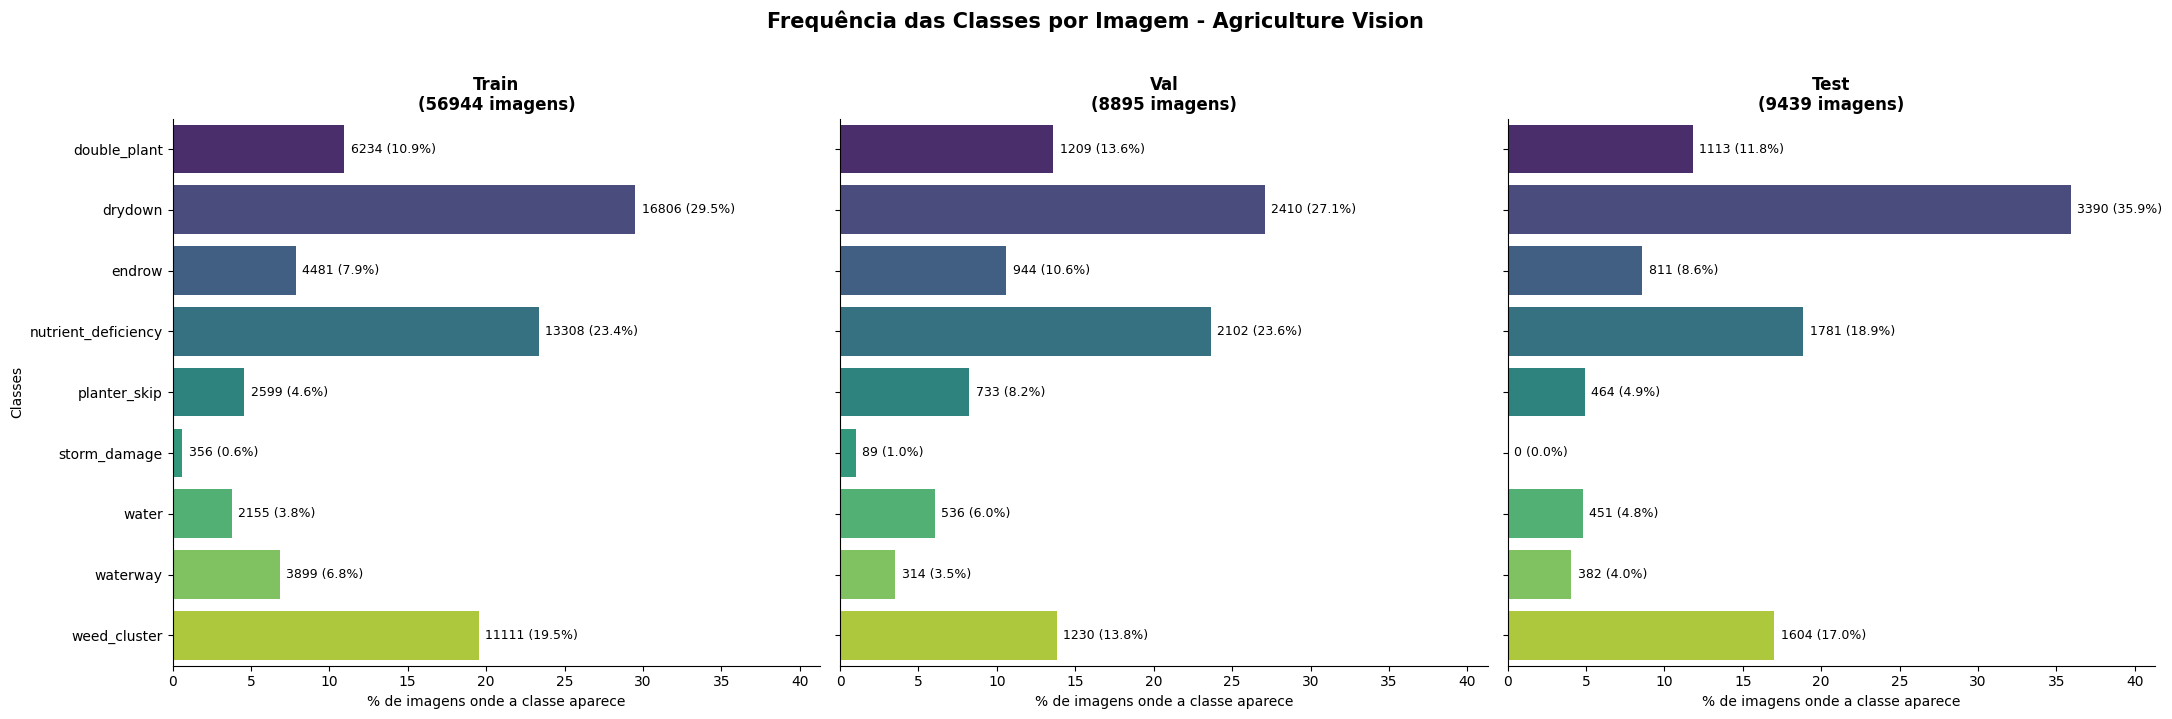

In [7]:
exploratory_data_analysis.plot_frequencia_classes([
    ("Train", metricas_train["contagem_imagens"], metricas_train["total_imagens"]),
    ("Val",   metricas_val["contagem_imagens"],   metricas_val["total_imagens"]),
    ("Test",  metricas_test["contagem_imagens"],  metricas_test["total_imagens"]),
])

## Área Total Ocupada por Classe (em Pixels)

Complementar à frequência por imagem, esta métrica revela o **peso físico** de cada classe — quantos pixels no total ela ocupa em cada split.

`drydown` (no Train) e `nutrient_deficiency` (no Train) dominam amplamente a área anotada, enquanto `planter_skip` e `storm_damage` ficam duas ordens de magnitude abaixo. **Esse desbalanceamento de área é relevante para a função de loss: modelos treinados sem ponderação tendem a ignorar as classes fisicamente menores**.

Vale notar que `weed_cluster` apresenta proporção de área visivelmente diferente entre Train e Val/Test.

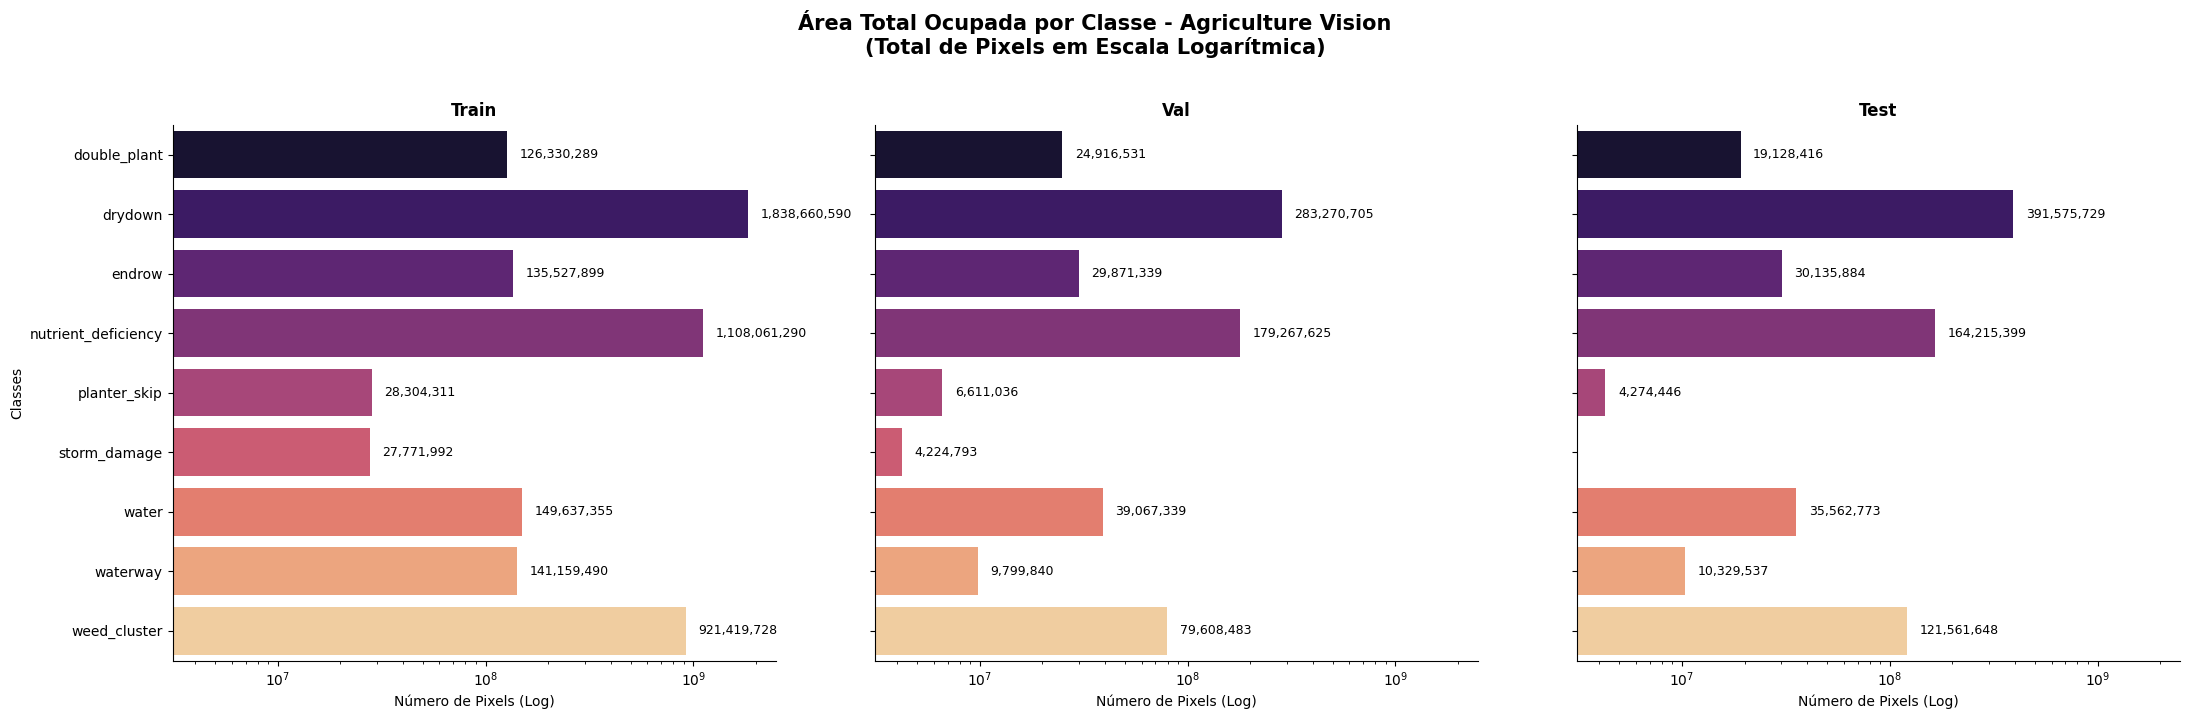

In [8]:
exploratory_data_analysis.plot_area_pixels_log([
    ("Train", metricas_train["contagem_pixels"]),
    ("Val",   metricas_val["contagem_pixels"]),
    ("Test",  metricas_test["contagem_pixels"]),
])


## Distribuição de Escala das Instâncias por Classe

Cada ponto representa uma instância anotada. O boxplot resume o comportamento de cada classe em relação sua escala. A linha vermelha marca a **área total da imagem (512 × 512 = 262.144 px)** como referência de escala máxima.

Classes como `drydown` e `nutrient_deficiency` frequentemente preenchem quase toda a imagem (512x512), vide mediana de seus boxplots e a densidade de pontos. E já `planter_skip` e `double_plant` são consistentemente mais compactas, vide a posição da caixa de seus boxplots.

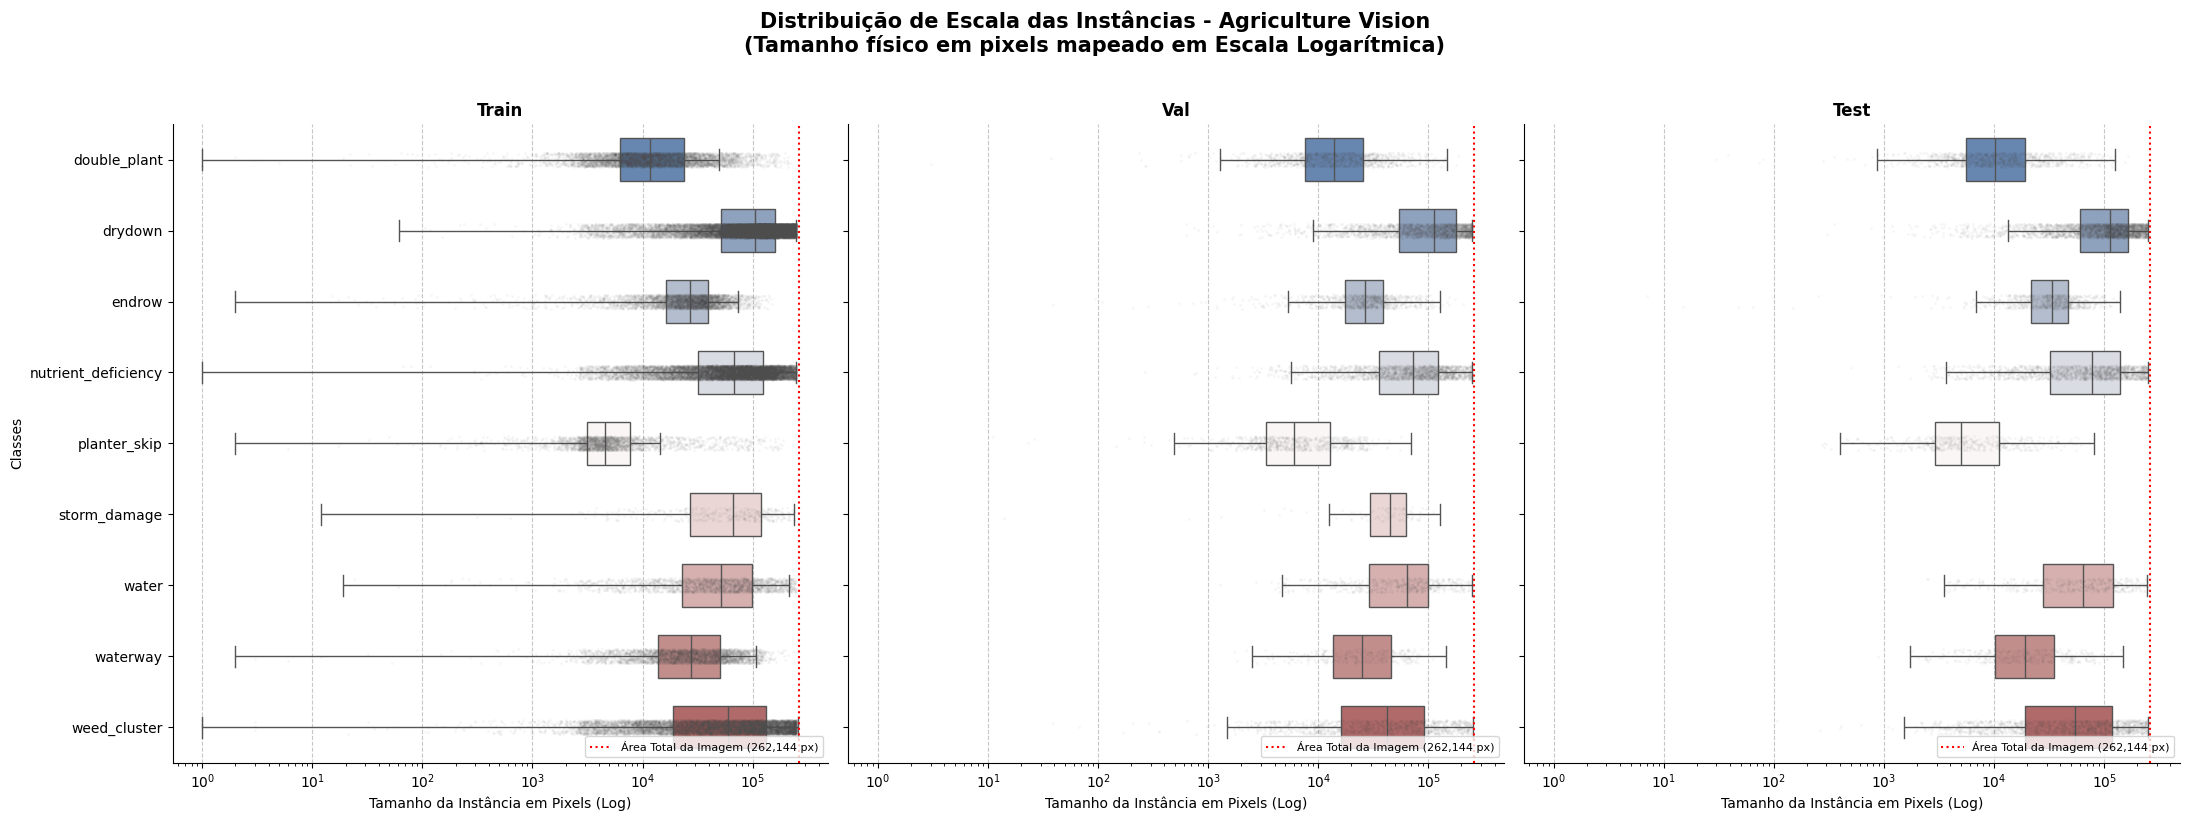

In [9]:
exploratory_data_analysis.plot_distribuicao_escala([
    ("Train", metricas_train["df_escala"]),
    ("Val",   metricas_val["df_escala"]),
    ("Test",  metricas_test["df_escala"]),
])

## Consistência do Split Adaptado

Para validar a adaptação, comparamos a distribuição de classes do **Val Original** com o **Val Adaptado**.

A preservação geral das proporções parece que confirma que o split por farmland não introduziu viés.

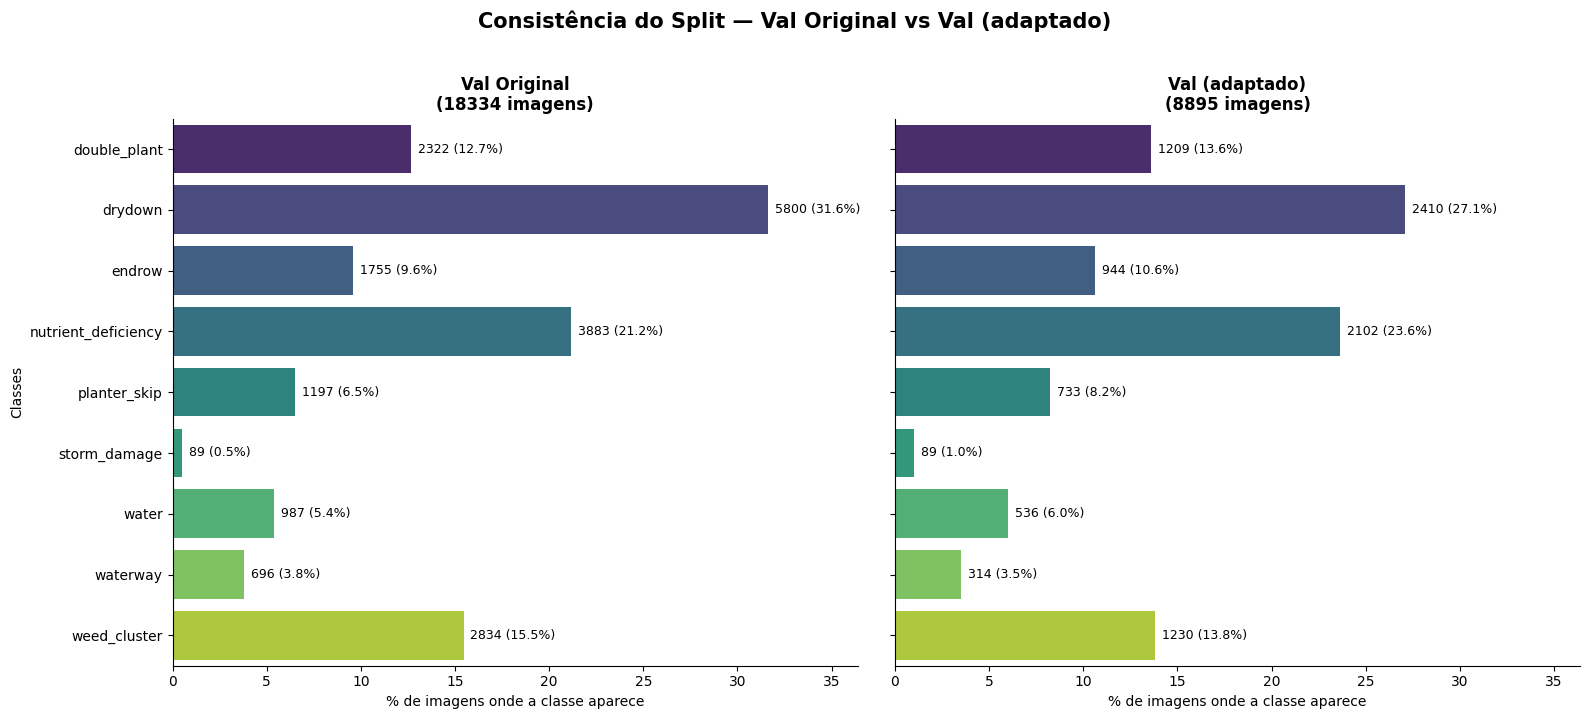

In [10]:
exploratory_data_analysis.plot_consistencia_split(metricas_val, metricas_test)